## **BAB 1: PENDAHULUAN DAN PERSIAPAN LINGKUNGAN**

### **1.1. Deskripsi Proyek & Tujuan Eksperimen**

Proyek ini memasuki fase krusial dalam *alignment pipeline*, yaitu penerapan *Reinforcement Learning* menggunakan metode *Generative Reward Policy Optimization* (GRPO). Berangkat dari model yang telah melewati tahap *Supervised Fine-Tuning* (SFT) pada fase sebelumnya, fokus utama notebook ini adalah menginduksi kemampuan penalaran logis (*reasoning*) secara eksplisit pada asisten AI hukum Indonesia.

Melalui GRPO, model tidak hanya dilatih untuk memberikan jawaban yang benar, tetapi juga dipaksa untuk melakukan dekonstruksi masalah hukum secara sistematis di dalam blok pemikiran khusus. Tahap ini merupakan penentu utama untuk mencapai performa asisten AI yang mampu meminimalisir halusinasi dan meningkatkan akurasi interpretasi peraturan perundang-undangan.

Tujuan utama dari eksperimen di notebook ini adalah:

1.  **Induksi Penalaran Logis:** Mengajari model untuk melakukan proses berpikir kritis menggunakan tag `<think>...</think>` sebelum merumuskan jawaban akhir.
2.  **Implementasi Reward Shaping:** Mengoptimalkan kebijakan model melalui empat fungsi *reward* (Format, Panjang Penalaran, Akurasi, dan Penalti Bahasa) untuk memastikan output yang dihasilkan memenuhi standar profesional hukum.
3.  **Optimasi Komputasi RL:** Mengonfigurasi *pipeline* pelatihan GRPO yang efisien pada infrastruktur GPU Tesla T4 dengan memanfaatkan kernel optimasi Unsloth.
4.  **Konsolidasi dan Deployment:** Melakukan fusi bobot (*merging*) adapter LoRA hasil GRPO ke dalam model dasar untuk menghasilkan model mandiri berpresisi 16-bit yang siap diintegrasikan ke dalam sistem *Advanced RAG*.

### **1.2. Instalasi Dependensi dan Import Libraries**

Tahap ini melakukan import libraries sertainstalasi pustaka yang diperlukan untuk optimasi kernel dan manajemen memori GPU. Penggunaan Unsloth sangat direkomendasikan untuk mempercepat proses *backpropagation* dan mengurangi penggunaan VRAM.


In [ ]:
import sys
import subprocess
import time
import os

# 1. AUTOMATED ENVIRONMENT SETUP & DYNAMIC IMPORTS
def setup_and_import_environment():
    """
    Mengorkestrasi instalasi dependensi dan pemuatan library secara dinamis.
    Memastikan urutan import yang benar (Unsloth pertama) untuk optimasi kernel.
    """
    print("[SYSTEM] Memeriksa dan menginstal dependensi kritis...")

    dependencies = [
        "unsloth", "xformers", "trl", "peft", "accelerate",
        "bitsandbytes", "wandb", "python-dotenv", "sentencepiece",
        "mergekit"
    ]

    command = [sys.executable, "-m", "pip", "install"] + dependencies + ["--quiet", "--disable-pip-version-check"]

    try:
        process_result = subprocess.run(command, capture_output=True, text=True)
        if process_result.returncode == 0:
            print("[SUCCESS] Seluruh dependensi berhasil diinstal.")
        else:
            print(f"[FATAL ERROR] Kegagalan instalasi: {process_result.stderr}")
            return False
    except Exception as e:
        print(f"[FATAL ERROR] Interupsi sistem: {str(e)}")
        return False

    # Deklarasi Global Scope
    global pd, sns, plt, WordCloud, torch, wandb, load_dataset, Dataset, login
    global SFTConfig, SFTTrainer, GRPOConfig, GRPOTrainer, LoraConfig, get_peft_model
    global TextStreamer, HfApi, tempfile, FastLanguageModel, PatchFastRL
    global get_chat_template, is_bfloat16_supported, UserSecretsClient, re, gc, json

    print("[SYSTEM] Memuat library ke dalam memori aktif...")

    try:
        # 1. UNSLOTH HARUS DI-IMPORT PERTAMA KALI (Mencegah UserWarning & Memory Leak)
        from unsloth import FastLanguageModel, PatchFastRL, get_chat_template, is_bfloat16_supported

        # 2. Standard & Data Science
        import pandas as pd
        import seaborn as sns
        import matplotlib.pyplot as plt
        from wordcloud import WordCloud
        import re, gc, json, tempfile
        from typing import List, Dict, Union

        # 3. ML Frameworks
        import torch
        import wandb
        from datasets import load_dataset, Dataset
        from huggingface_hub import login, HfApi

        # 4. LLM Specifics (TRL, PEFT, Transformers)
        from trl import SFTConfig, SFTTrainer, GRPOConfig, GRPOTrainer
        from peft import LoraConfig, get_peft_model
        from transformers import TextStreamer
        from kaggle_secrets import UserSecretsClient

        print("[SUCCESS] Seluruh library berhasil dimuat dengan urutan optimasi yang benar.")
        return True

    except Exception as import_error:
        print(f"[FATAL ERROR] Gagal memuat library: {str(import_error)}")
        return False

# 2. EXECUTION
installation_start = time.time()

if setup_and_import_environment():
    installation_end = time.time()
    print(f"[SYSTEM] Operasi pipeline inisialisasi selesai dalam {installation_end - installation_start:.2f} detik.")
else:
    print("[ERROR] Pipeline inisialisasi gagal. Periksa koneksi internet atau kuota GPU Anda.")

[SYSTEM] Memeriksa dan menginstal dependensi kritis...
[SUCCESS] Seluruh dependensi berhasil diinstal.
[SYSTEM] Memuat library ke dalam memori aktif...
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
[SUCCESS] Seluruh library berhasil dimuat dengan urutan optimasi yang benar.
[SYSTEM] Operasi pipeline inisialisasi selesai dalam 107.29 detik.


### **1.3. Konfigurasi Kredensial & Logging**

Manajemen sesi eksperimen dilakukan melalui integrasi Hugging Face Hub untuk penyimpanan model dan Weights & Biases (W&B) untuk pelacakan metrik *loss* serta performa perangkat keras secara real-time.


In [ ]:
def setup_credentials():
    """
    Mengatur autentikasi untuk layanan eksternal di lingkungan Kaggle.
    Mengambil token dari Kaggle Secrets secara aman.
    """
    print("Memulai proses autentikasi di lingkungan Kaggle...")

    try:
        # Inisialisasi Kaggle Secrets Client
        user_secrets = UserSecretsClient()

        # Mengambil token dari Kaggle Secrets
        # Pastikan nama label di UI Secrets Kaggle sama persis (Case Sensitive)
        hf_token = user_secrets.get_secret("HF_TOKEN")
        wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")

        # Autentikasi Hugging Face
        if hf_token:
            login(token=hf_token)
            print("[SUCCESS] Hugging Face token berhasil dimuat.")
        else:
            print("[WARNING] HF_TOKEN tidak ditemukan di Kaggle Secrets.")

        # Autentikasi Weights & Biases
        if wandb_api_key:
            wandb.login(key=wandb_api_key)
            print("[SUCCESS] Weights & Biases API key berhasil dimuat.")
        else:
            print("[WARNING] WANDB_API_KEY tidak ditemukan. Logging akan terbatas.")

    except Exception as e:
        print(f"[ERROR] Gagal mengakses Kaggle Secrets: {e}")
        print("Pastikan Anda telah menambahkan 'HF_TOKEN' dan 'WANDB_API_KEY' di menu Add-ons -> Secrets.")

# Eksekusi inisialisasi kredensial
setup_credentials()

Memulai proses autentikasi di lingkungan Kaggle...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


[SUCCESS] Hugging Face token berhasil dimuat.


wandb: Currently logged in as: datasciencelatief (datasciencelatief-universitas-teknologi-yogyakarta) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[SUCCESS] Weights & Biases API key berhasil dimuat.


### **1.4. Penentuan Hyperparameter Global**

Konfigurasi di bawah ini mencakup parameter arsitektur model dan strategi pelatihan. Terdapat mekanisme `DEBUG_MODE` untuk melakukan validasi alur kerja secara cepat sebelum menjalankan pelatihan penuh.


In [ ]:
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class TrainingConfig:
    """
    Menyimpan konfigurasi global untuk proses fine-tuning.
    Termasuk logika untuk mode debugging dan optimasi arsitektur.
    """
    # Konfigurasi Model
    model_name: str = "unsloth/meta-llama-3.1-8b-bnb-4bit"
    max_seq_length: int = 2048
    load_in_4bit: bool = True

    # Konfigurasi LoRA
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.0  # WAJIB 0.0 untuk mengaktifkan optimasi kernel Unsloth
    target_modules: list = field(default_factory=lambda: [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ])

    # Konfigurasi Training Umum
    dataset_name: str = "ichsan2895/alpaca-gpt4-indonesian"
    output_dir: str = "outputs/llama-3.1-legal-sft"
    seed: int = 42

    # Mode Debugging
    DEBUG_MODE: bool = False # Ubah ke True untuk pengujian cepat (10 steps)

    def get_training_args(self):
        """
        Mengembalikan argumen pelatihan berdasarkan status DEBUG_MODE.
        """
        if self.DEBUG_MODE:
            return {
                "max_steps": 10,
                "logging_steps": 1,
                "save_steps": 5,
                "eval_steps": 5,
                "per_device_train_batch_size": 1,
                "gradient_accumulation_steps": 1,
                "learning_rate": 2e-4
            }
        else:
            return {
                "max_steps": 800,
                "logging_steps": 10,
                "save_steps": 100,
                "eval_steps": 100,
                "per_device_train_batch_size": 2,
                "gradient_accumulation_steps": 4,
                "learning_rate": 2e-4
            }

# Inisialisasi konfigurasi
config = TrainingConfig(DEBUG_MODE=False)
training_params = config.get_training_args()

# Verifikasi parameter aktif
print(f"[SYSTEM] Konfigurasi dimuat. Mode Debug: {config.DEBUG_MODE}")
print(f"[SYSTEM] Langkah pelatihan maksimum: {training_params['max_steps']}")
print(f"[SYSTEM] LoRA Dropout disetel ke: {config.lora_dropout} (Optimasi Unsloth Aktif)")

[SYSTEM] Konfigurasi dimuat. Mode Debug: False
[SYSTEM] Langkah pelatihan maksimum: 800
[SYSTEM] LoRA Dropout disetel ke: 0.0 (Optimasi Unsloth Aktif)


## **BAB 2: DEEP EXPLORATORY DATA ANALYSIS (EDA)**

### **2.1. Pemuatan Dataset**

Tahap awal EDA dimulai dengan memuat dataset dari Hugging Face Hub. Dataset `ichsan2895/alpaca-gpt4-indonesian` dipilih karena merupakan hasil translasi dan augmentasi berkualitas tinggi yang menggunakan engine GPT-4, sehingga memiliki struktur semantik yang lebih baik dibandingkan versi standar.

In [ ]:
def load_and_convert_to_pandas(dataset_name: str) -> pd.DataFrame:
    """
    Memuat dataset dari Hugging Face dan mengonversinya ke format Pandas DataFrame
    untuk mempermudah manipulasi data dan analisis statistik.
    """
    try:
        dataset = load_dataset(dataset_name, split="train")
        df = pd.DataFrame(dataset)
        print(f"Dataset {dataset_name} berhasil dimuat.")
        print(f"Total baris data: {len(df)}")
        return df
    except Exception as e:
        print(f"Error saat memuat dataset: {e}")
        return pd.DataFrame()

# Eksekusi pemuatan data
df_eda = load_and_convert_to_pandas(config.dataset_name)

README.md: 0.00B [00:00, ?B/s]

alpaca-gpt4-indonesia.csv:   0%|          | 0.00/41.4M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset ichsan2895/alpaca-gpt4-indonesian berhasil dimuat.
Total baris data: 49969


### **2.2. Inspeksi Struktur Data**

Melakukan validasi terhadap integritas struktural dataset. Fokus utama adalah mengidentifikasi keberadaan nilai null, duplikasi data, serta distribusi kolom yang tersedia.


In [ ]:
def inspect_data_structure(raw_dataframe: pd.DataFrame) -> None:
    """
    Melakukan inspeksi analitik terhadap struktur DataFrame mentah.
    Fungsi ini bersifat murni observasional (read-only) dan tidak melakukan
    mutasi atau manipulasi data (seperti drop inplace) untuk menjaga integritas
    tahap Exploratory Data Analysis.

    Args:
        raw_dataframe (pd.DataFrame): Dataset mentah hasil pemuatan awal.
    """
    print("--- Laporan Inspeksi Struktur Data ---")

    # 1. Analisis Tipe Data dan Memori
    print("\n[LOG] Profiling Skema DataFrame:")
    print(raw_dataframe.info())

    # 2. Analisis Kelengkapan Data (Missing Values)
    print("\n[LOG] Deteksi Nilai Kosong (Null/NaN):")
    null_counts = raw_dataframe.isnull().sum()
    print(null_counts)

    if null_counts.sum() > 0:
        print("[WARNING] Ditemukan nilai kosong. Membutuhkan penanganan pada tahap preprocessing.")
    else:
        print("[STATUS] Integritas kelengkapan data tervalidasi (0 Null).")

    # 3. Analisis Duplikasi Data
    # Menggunakan kolom 'input' karena pada tahap ini belum dilakukan proses rename
    print("\n[LOG] Deteksi Duplikasi Observasi:")
    if 'input' in raw_dataframe.columns and 'output' in raw_dataframe.columns:
        duplicate_count = raw_dataframe.duplicated(subset=['input', 'output']).sum()
        print(f"Jumlah observasi duplikat terdeteksi: {duplicate_count}")

        if duplicate_count > 0:
            print("[RECOMMENDATION] Duplikasi terdeteksi. Wajib dilakukan eliminasi pada Bab 3 (Preprocessing).")
    else:
        print("[WARNING] Kolom 'input' atau 'output' tidak ditemukan untuk analisis duplikasi.")

# Eksekusi inspeksi data (Menggunakan df_eda dari Bab 2.1)
inspect_data_structure(df_eda)

--- Laporan Inspeksi Struktur Data ---

[LOG] Profiling Skema DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49969 entries, 0 to 49968
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  49969 non-null  int64 
 1   input       49969 non-null  object
 2   output      49969 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB
None

[LOG] Deteksi Nilai Kosong (Null/NaN):
Unnamed: 0    0
input         0
output        0
dtype: int64
[STATUS] Integritas kelengkapan data tervalidasi (0 Null).

[LOG] Deteksi Duplikasi Observasi:
Jumlah observasi duplikat terdeteksi: 1
[RECOMMENDATION] Duplikasi terdeteksi. Wajib dilakukan eliminasi pada Bab 3 (Preprocessing).


### **2.3. Analisis Statistik Panjang Teks (Tokenization Analysis)**

LLM memiliki batasan context window. Analisis ini bertujuan untuk menentukan distribusi panjang kata pada kolom instruction dan output guna menentukan parameter `max_seq_length` yang optimal tanpa membuang informasi penting.


--- Statistik Deskriptif Panjang Kata (Word Count) ---
       input_word_count  output_word_count
count      49969.000000       49969.000000
mean          13.013048          98.551742
std           12.118800          92.841084
min            1.000000           1.000000
25%            7.000000          16.000000
50%           10.000000          70.000000
75%           15.000000         164.000000
90%           22.000000         240.000000
95%           29.000000         277.000000
99%           62.000000         343.000000
max          631.000000         920.000000


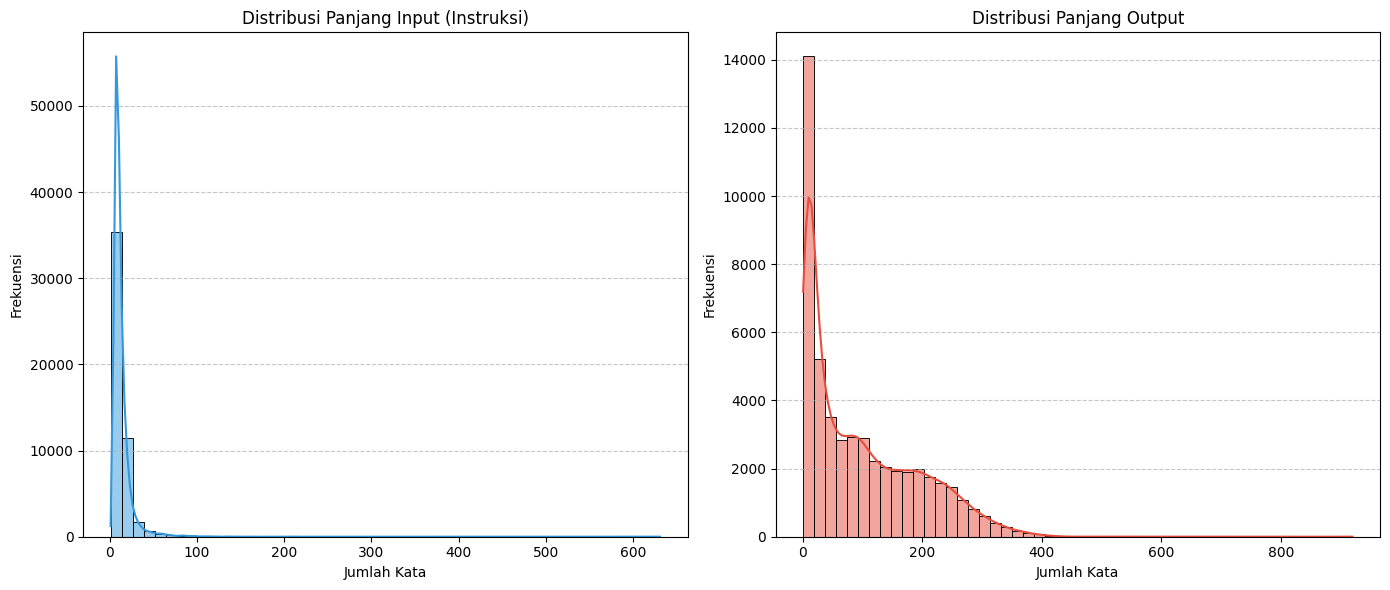

In [ ]:
def analyze_text_length(df: pd.DataFrame):
    """
    Melakukan analisis statistik panjang teks pada kolom instruksi (input) dan output.
    Menghitung jumlah kata sebagai proksi untuk estimasi token (estimasi token = 1.5x - 2x jumlah kata).

    Args:
        df (pd.DataFrame): DataFrame yang berisi dataset asli.
    """
    # Validasi keberadaan kolom sebelum kalkulasi
    required_columns = ['input', 'output']
    if not all(col in df.columns for col in required_columns):
        raise ValueError(f"DataFrame harus mengandung kolom: {required_columns}")

    # Kalkulasi panjang kata (Word Count)
    # Gunakan .str.split().str.len() untuk performa lebih baik pada pandas
    df['input_word_count'] = df['input'].str.split().str.len()
    df['output_word_count'] = df['output'].str.split().str.len()

    # Statistik deskriptif dengan percentiles yang relevan untuk batas model
    stats = df[['input_word_count', 'output_word_count']].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )

    print("--- Statistik Deskriptif Panjang Kata (Word Count) ---")
    print(stats)

    # Visualisasi menggunakan subplot yang lebih rapi
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Input (Instruksi)
    sns.histplot(df['input_word_count'], bins=50, kde=True, ax=axes[0], color='#3498db')
    axes[0].set_title('Distribusi Panjang Input (Instruksi)')
    axes[0].set_xlabel('Jumlah Kata')
    axes[0].set_ylabel('Frekuensi')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Plot Output
    sns.histplot(df['output_word_count'], bins=50, kde=True, ax=axes[1], color='#e74c3c')
    axes[1].set_title('Distribusi Panjang Output')
    axes[1].set_xlabel('Jumlah Kata')
    axes[1].set_ylabel('Frekuensi')
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Menjalankan analisis panjang teks
analyze_text_length(df_eda)

### **2.4. Analisis Linguistik & Semantik**

Untuk mengatasi masalah *noise* pada visualisasi, kode berikut telah dimodifikasi dengan mengimplementasikan pembersihan *stopwords* Bahasa Indonesia dan pembersihan teks (*preprocessing*). Hal ini memastikan *WordCloud* hanya menampilkan kata-kata bermakna yang merepresentasikan konten dataset.


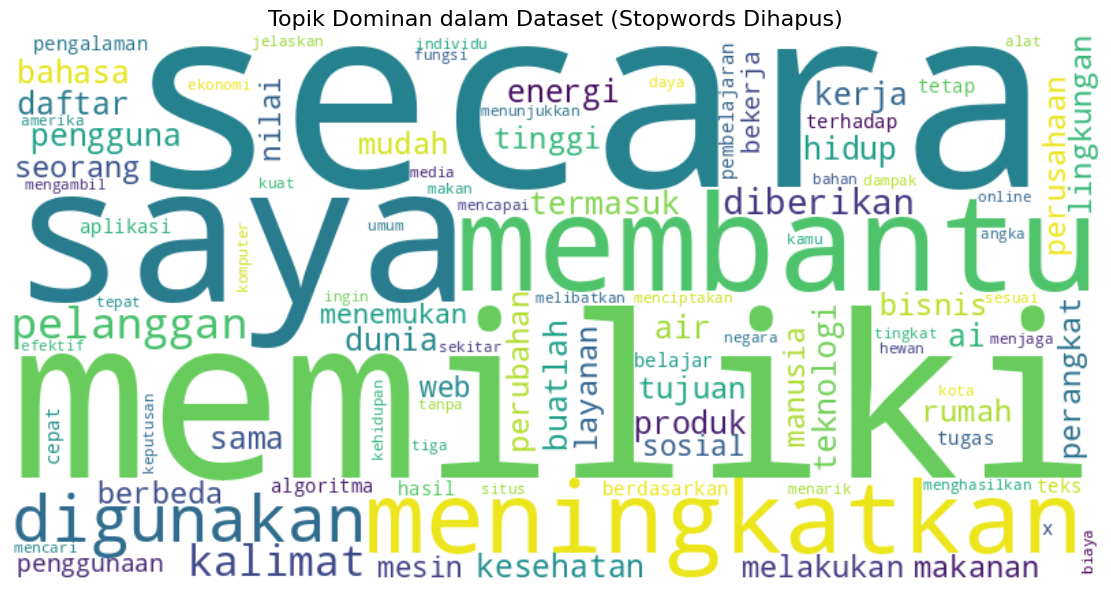

In [ ]:
def analyze_content_topics(df: pd.DataFrame):
    """
    Menghasilkan visualisasi WordCloud yang telah dibersihkan dari stop words
    untuk mengidentifikasi topik dominan dalam dataset.
    """
    # Daftar stop words Bahasa Indonesia yang umum dan lebih rinci
    stopwords = [
        'ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir',
        'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar',
        'antara', 'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'artinya',
        'asal', 'asalkan', 'atas', 'atau', 'ataukah', 'ataupun', 'awal', 'awalnya', 'bagai',
        'bagaikan', 'bagaimana', 'bagaimanakah', 'bagaimanapun', 'bagi', 'bagian', 'bahkan',
        'bahwa', 'bahwasanya', 'baik', 'bakal', 'bakalan', 'balik', 'banyak', 'bapak', 'baru',
        'bawah', 'beberapa', 'begini', 'beginian', 'beginikah', 'beginilah', 'begitu', 'begitukah',
        'begitulah', 'begitupun', 'bekas', 'belakang', 'belakangan', 'belum', 'belumlah', 'benar',
        'benarkah', 'benarlah', 'berada', 'berapa', 'berapakah', 'berapalah', 'berapapun', 'berarti',
        'berawal', 'berbagai', 'berdatangan', 'beri', 'berikan', 'berikut', 'berikutnya', 'berjumlah',
        'berkali-kali', 'berkata', 'berkehendak', 'berkisar', 'berlalu', 'berlangsung', 'berlebihan',
        'bermacam', 'bermacam-macam', 'berpaling', 'berpendapat', 'bertempo', 'bertanya', 'berturut',
        'berturut-turut', 'bertutur', 'berujar', 'berupa', 'besar', 'betul', 'betulkah', 'biasa',
        'biasanya', 'bila', 'bilakah', 'bisa', 'bisakah', 'boleh', 'bolehkah', 'bolehlah', 'buat',
        'bukan', 'bukankah', 'bukanlah', 'bung', 'cara', 'caranya', 'cukup', 'cukupkah', 'cukuplah',
        'cuma', 'dahulu', 'dalam', 'dan', 'dapat', 'dari', 'daripada', 'datang', 'demi', 'demikian',
        'demikianlah', 'dengan', 'depan', 'di', 'dia', 'dialah', 'disebut', 'disebutkan', 'disebutnya',
        'diri', 'dirinya', 'doa', 'doi', 'dulu', 'dengan', 'dua', 'turut', 'terlebih', 'lebih-lebih',
        'mungkin', 'tentang', 'apa', 'dari', 'saat', 'sebuah', 'seperti', 'selain', 'tidak', 'ini',
        'itu', 'dan', 'yang', 'untuk', 'dengan', 'sebagai', 'lebih', 'dapat', 'oleh', 'pada', 'juga',
        'akan', 'salah', 'satu', 'dalam', 'jika', 'atau', 'mereka', 'anda', 'kita', 'memberikan',
        'tersebut', 'seperti', 'bisa', 'menjadi', 'terdapat', 'paling', 'sangat', 'namun',
        'guna', 'habis', 'hal', 'hampir', 'hanya', 'hanyalah', 'hari', 'harus', 'haruslah', 'harusnya',
        'hendak', 'hendaklah', 'hendaknya', 'hingga', 'ia', 'ialah', 'ibarat', 'ikut', 'ikuti',
        'ikutlah', 'inikah', 'inilah', 'itu', 'itukah', 'itulah', 'jadi', 'jadilah', 'jadinya', 'jangan',
        'jangankah', 'janganlah', 'jauh', 'jauhnya', 'jika', 'jikalau', 'juga', 'jumlah', 'jumlahnya',
        'justru', 'kadar', 'kala', 'kalau', 'kalaulah', 'kalaupun', 'kalian', 'kami', 'kamilah', 'kan',
        'kapan', 'kapankah', 'kapanpun', 'karena', 'karenanya', 'kata', 'katanya', 'ke', 'kecil',
        'kedua', 'keduanya', 'kekal', 'kembali', 'kemudian', 'kepada', 'kepadanya', 'keseluruhan',
        'ketika', 'khususnya', 'kini', 'kinilah', 'kira', 'kiranya', 'kita', 'kitalah', 'kok', 'kurang',
        'lagi', 'lagian', 'lah', 'lain', 'lainnya', 'lalu', 'lama', 'lamanya', 'langsung', 'lebih',
        'lewat', 'lihat', 'maka', 'makanya', 'makin', 'malah', 'malahan', 'mampu', 'mampukah',
        'mana', 'manakala', 'manapun', 'masih', 'masihkah', 'masing', 'mau', 'maupun', 'memang',
        'memastikan', 'memberi', 'memberikan', 'membuat', 'memperkirakan', 'memulai', 'memungkinkan',
        'menaiki', 'menambah', 'menambahkan', 'menentukan', 'mengadakan', 'mengapa', 'mengapakah',
        'mengeluarkan', 'menggunakan', 'menghendaki', 'mengira', 'mengurangi', 'menjadi', 'menuju',
        'menurut', 'menyatakan', 'menyebabkan', 'menyuruh', 'mereka', 'merekalah', 'merupakan',
        'meskipun', 'mestinya', 'mula', 'mulai', 'mulailah', 'muncul', 'mungkin', 'mungkinkah',
        'nah', 'namun', 'nanti', 'nantinya', 'nyaris', 'nyatanya', 'oleh', 'olehnya', 'orang',
        'pada', 'padahal', 'padanya', 'pak', 'paling', 'panjang', 'pantaskah', 'para', 'pasti',
        'pastilah', 'penting', 'pentingnya', 'per', 'percuma', 'perlu', 'perlukah', 'perlunya',
        'pernah', 'persoalan', 'pertama', 'pertama-tama', 'setiap', 'tiap', 'para', 'tersebut',
        'adalah', 'yakni', 'yaitu', 'ia', 'dia', 'kami', 'kita', 'kalian', 'mereka', 'semua', 'hal',
        'itu', 'ini', 'guna', 'bagi', 'oleh', 'untuk', 'pada', 'saat', 'sebelum', 'sesudah', 'setelah',
        'kemudian', 'lalu', 'sedangkan', 'tetapi', 'namun', 'maka', 'dan', 'atau', 'apabila', 'jika',
        'kalau', 'supaya', 'agar', 'kecuali', 'sehingga', 'meskipun', 'sekalipun', 'walaupun',
        'bahwa', 'karena', 'sebab', 'dengan', 'cara', 'menurut', 'menuju', 'melalui', 'sampai',
        'selama', 'seperti', 'sebagaimana', 'seraya', 'ketika', 'dari', 'ke', 'di', 'pun', 'lah',
        'kah', 'nya', 'ku', 'mu', 'saja', 'juga', 'pula', 'begitu', 'demikian', 'hanya', 'cuma',
        'terlalu', 'amat', 'sangat', 'sekali', 'agak', 'kira-kira', 'hampir', 'pasti', 'tentu',
        'memang', 'sudah', 'telah', 'belum', 'akan', 'masih', 'sedang', 'pernah', 'tidak', 'bukan',
        'jangan', 'silakan', 'tolong', 'mari', 'ayo', 'ya', 'oh', 'wow', 'aduh', 'wah', 'eh',
        'mengenai', 'antara', 'lain', 'lainnya', 'sendiri', 'sendirian', 'berbagai', 'segala',
        'seluruh', 'selama', 'setiap', 'tiap', 'masing-masing', 'suatu', 'tertentu', 'beberapa',
        'banyak', 'sedikit', 'semua', 'seluruhnya', 'sebagian', 'sering', 'jarang', 'kadang-kadang',
        'selalu', 'senantiasa', 'terkadang', 'seringkali', 'biasanya', 'umumnya', 'khususnya',
        'terutama', 'penting', 'utama', 'pokok', 'dasar', 'fondasi', 'inti', 'pusat', 'awal', 'akhir',
        'puncak', 'buntut', 'ujung', 'depan', 'belakang', 'samping', 'atas', 'bawah', 'dalam',
        'luar', 'tengah', 'kanan', 'kiri', 'sini', 'situ', 'sana', 'mana', 'mana-mana', 'di mana',
        'ke mana', 'dari mana', 'bagaimana', 'berapa', 'kapan', 'siapa', 'mengapa', 'apa', 'apa-apa',
        'siapa-siapa', 'kapan-kapan', 'di mana-mana', 'ke mana-mana', 'dari mana-mana', 'seperti',
        'sebagai', 'selaku', 'ibarat', 'laksana', 'bak', 'umpama', 'misalnya', 'contohnya',
        'antara lain', 'dan lain-lain', 'dst', 'dsb', 'yaitu', 'yakni', 'ialah', 'adalah', 'yaitu',
        'yaitu', 'yakni', 'itulah', 'inilah', 'itu', 'ini', 'tersebut', 'demikian', 'begitu',
        'demikianlah', 'begitulah', 'sekian', 'selesai', 'mari', 'ayo', 'silakan', 'tolong',
        'mohon', 'harap', 'jangan', 'tidak', 'bukan', 'memang', 'pasti', 'tentu', 'nyata',
        'sesungguhnya', 'sebenarnya', 'faktanya', 'pada dasarnya', 'intinya', 'kesimpulannya',
        'jadi', 'maka', 'oleh karena itu', 'dengan demikian', 'akibatnya', 'hasilnya', 'namun',
        'tetapi', 'meskipun', 'walaupun', 'biarpun', 'sekalipun', 'meski', 'padahal', 'sedangkan',
        'sementara', 'serta', 'beserta', 'bersama', 'berdampingan', 'berkaitan', 'berhubungan',
        'terkait', 'bertalian', 'berkaitan dengan', 'terkait dengan', 'sehubungan dengan',
        'berkenaan dengan', 'tentang', 'mengenai', 'perihal', 'soal', 'masalah', 'kasus',
        'fenomena', 'kejadian', 'peristiwa', 'hal', 'aspek', 'faktor', 'elemen', 'unsur',
        'komponen', 'bagian', 'sektor', 'bidang', 'area', 'wilayah', 'daerah', 'lokasi',
        'tempat', 'posisi', 'arah', 'jurusan', 'sisi', 'sebelah', 'antara', 'di antara',
        'menuju', 'ke arah', 'dari arah', 'hingga', 'sampai', 'sejak', 'mulai', 'berawal',
        'berakhir', 'selama', 'sepanjang', 'sewaktu', 'ketika', 'saat', 'tatkala', 'manakala',
        'begitu', 'segera', 'langsung', 'kemudian', 'lalu', 'setelah', 'sesudah', 'sebelum',
        'mendahului', 'mengikuti', 'menyusul', 'tiba', 'datang', 'berangkat', 'pergi', 'pulang',
        'kembali', 'kembali ke', 'pergi ke', 'datang dari', 'keluar dari', 'masuk ke',
        'meninggalkan', 'tiba di', 'tiba pada', 'terjadi', 'berlaku', 'berlangsung', 'berada',
        'bertujuan', 'bertujuan untuk', 'maksudnya', 'artinya', 'maknanya', 'definisinya',
        'penjelasannya', 'uraiannya', 'gambaran', 'representasi', 'ilustrasi', 'contoh',
        'model', 'pola', 'bentuk', 'jenis', 'macam', 'golongan', 'kategori', 'klasifikasi',
        'tipe', 'variasi', 'ragam', 'alternatif', 'pilihan', 'opsi', 'kemungkinan',
        'peluang', 'potensi', 'kapasitas', 'kemampuan', 'kompetensi', 'keahlian',
        'keterampilan', 'pengetahuan', 'informasi', 'data', 'fakta', 'bukti', 'argumen',
        'alasan', 'dasar', 'prinsip', 'konsep', 'teori', 'hipotesis', 'premis', 'postulat',
        'asumsi', 'pandangan', 'opini', 'pendapat', 'persepsi', 'perspektif', 'sudut pandang',
        'penyebab', 'faktor', 'sumber', 'asal', 'muasal', 'akar', 'inti', 'pokok', 'dasar',
        'awal', 'mula', 'akhir', 'ujung', 'puncak', 'klimaks', 'resolusi', 'solusi',
        'penyelesaian', 'jawaban', 'respons', 'tanggapan', 'reaksi', 'aksi', 'tindakan',
        'langkah', 'upaya', 'usaha', 'strategi', 'metode', 'teknik', 'pendekatan', 'cara',
        'mekanisme', 'sistem', 'prosedur', 'tahapan', 'proses', 'siklus', 'periode',
        'masa', 'waktu', 'zaman', 'era', 'detik', 'menit', 'jam', 'hari', 'minggu', 'bulan',
        'tahun', 'abad', 'milenium', 'sekarang', 'saat ini', 'kini', 'dahulu', 'dulu',
        'lampau', 'masa lalu', 'masa depan', 'nanti', 'besok', 'lusa', 'kemarin', 'tadi'
    ]

    # Menggabungkan teks input dan output
    combined_text = " ".join(df['input'].astype(str)) + " " + " ".join(df['output'].astype(str))

    # Preprocessing teks: konversi ke lowercase dan hapus karakter non-alfabet
    clean_text = combined_text.lower()
    clean_text = re.sub(r'[^a-z\s]', '', clean_text)

    # Menghapus stop words menggunakan regex untuk akurasi pencocokan kata
    pattern = r'\b(?:' + '|'.join(stopwords) + r')\b'
    clean_text = re.sub(pattern, '', clean_text)

    # Konfigurasi WordCloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100,
        colormap='viridis',
        collocations=False # Menghindari pengulangan kata yang sama
    ).generate(clean_text)

    # Visualisasi
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Topik Dominan dalam Dataset (Stopwords Dihapus)', fontsize=16)
    plt.tight_layout()
    plt.show()

# Menjalankan analisis topik
analyze_content_topics(df_eda)

### **2.5. Analisis Kolom Input (Contextual Analysis)**

Dalam format Alpaca, kolom `input` seringkali kosong. Analisis ini menentukan seberapa sering konteks tambahan diberikan kepada model, yang sangat relevan untuk skenario RAG di masa depan.


In [ ]:
def analyze_input_usage(df: pd.DataFrame):
    """
    Menganalisis rasio penggunaan kolom 'input'.
    Jika rasio rendah, model mungkin perlu dilatih lebih kuat pada instruksi mandiri (zero-shot).
    """
    empty_input_count = (df['input'].str.strip() == "").sum()
    total_count = len(df)
    usage_ratio = ((total_count - empty_input_count) / total_count) * 100

    print("\n--- Analisis Penggunaan Kolom Input ---")
    print(f"Data dengan input terisi: {total_count - empty_input_count}")
    print(f"Data dengan input kosong: {empty_input_count}")
    print(f"Rasio penggunaan input: {usage_ratio:.2f}%")

# Menjalankan analisis input
analyze_input_usage(df_eda)


--- Analisis Penggunaan Kolom Input ---
Data dengan input terisi: 49969
Data dengan input kosong: 0
Rasio penggunaan input: 100.00%


### **2.6. Kesimpulan EDA & Strategi Preprocessing**



**Ringkasan Hasil Analisis Data**

Dataset yang digunakan kini berada dalam kondisi yang sangat prima dengan total 49.968 baris data yang bersih dari nilai kosong maupun duplikasi. Hasil inspeksi menunjukkan bahwa dataset ini memiliki konsistensi struktur yang tinggi. Berdasarkan distribusi panjang teks, mayoritas instruksi bersifat ringkas dengan rata rata 13 kata, sementara respons model memiliki panjang yang lebih variatif dengan rata rata 98 kata. Nilai maksimum sebanyak 920 kata pada kolom respons mengonfirmasi bahwa penggunaan panjang sekuens sebesar 2048 token sudah sangat ideal karena mampu mengakomodasi data terpanjang sekalipun tanpa risiko pemotongan informasi yang penting. Visualisasi kata kunci setelah penghapusan kata sambung menunjukkan bahwa dataset mengandung banyak terminologi formal, teknis, dan sosial yang sangat mendukung kebutuhan pengembangan asisten AI hukum.

**Strategi Preprocessing dan Persiapan Training**

Langkah pertama dalam tahap preprocessing adalah pembersihan struktur dataset untuk memenuhi standar input model. Kolom Unnamed: 0 akan dihapus secara permanen karena tidak memiliki nilai informatif dan hanya membuang memori sistem. Sebagai langkah kunci untuk sinkronisasi dengan standar library training, kolom input akan diubah namanya menjadi instruction. Hal ini penting agar pipeline pelatihan mengenali kolom tersebut sebagai perintah utama yang harus dipelajari oleh model.

Mengingat seluruh baris data memiliki konten yang terisi, model akan dilatih untuk selalu memahami konteks yang diberikan dalam setiap instruksi. Strategi pembentukan format prompt akan mengikuti pola instruksi standar untuk memastikan model dapat membedakan antara perintah dan jawaban dengan jelas. Kami tidak perlu melakukan filtering tambahan karena kualitas dataset sudah sangat baik pasca penghapusan duplikasi. Langkah terakhir sebelum memulai fase pelatihan adalah memastikan konfigurasi tokenizer menggunakan pengaturan panjang sekuens yang telah ditentukan agar efisiensi komputasi terjaga namun tetap mempertahankan akurasi respons model. Dengan persiapan data yang sudah terstruktur dengan baik ini, model akan memiliki fondasi yang kuat untuk mempelajari pola bahasa hukum yang formal dan profesional.

## **BAB 3: DATA PREPROCESSING & TEMPLATING**

### **3.1. Pembersihan dan Penataan Ulang Dataset**

Berdasarkan temuan pada tahap EDA, langkah pertama adalah melakukan normalisasi skema dataset. Hal ini meliputi penghapusan kolom artefak, pemetaan ulang nama kolom agar sesuai dengan standar instruksi, serta eliminasi data duplikat untuk menjamin integritas proses pembelajaran model.


In [ ]:
def execute_data_cleaning(raw_dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Melakukan sanitasi dan transformasi struktural pada dataset mentah.
    Fungsi ini memusatkan seluruh operasi mutasi data (drop, rename, deduplikasi)
    sebelum data masuk ke dalam pipeline tokenisasi.

    Args:
        raw_dataframe (pd.DataFrame): Dataset mentah hasil pemuatan awal.

    Returns:
        pd.DataFrame: Dataset yang telah divalidasi, dibersihkan, dan siap diproses.
    """
    print("[SYSTEM] Memulai proses pembersihan dan transformasi dataset...")

    if raw_dataframe is None or raw_dataframe.empty:
        raise ValueError("Kesalahan Fatal: Dataset input kosong atau tidak terdefinisi.")

    # Membuat salinan independen untuk mencegah modifikasi pada memori dataset asli
    cleaned_df = raw_dataframe.copy()

    # 1. Eliminasi kolom indeks residual dan kolom analitik sementara
    garbage_columns = ['Unnamed: 0', 'input_len', 'output_len', 'input_word_count', 'output_word_count']
    columns_to_drop = [col for col in garbage_columns if col in cleaned_df.columns]

    if columns_to_drop:
        cleaned_df = cleaned_df.drop(columns=columns_to_drop)
        print(f"[LOG] Kolom residu berhasil dieliminasi: {columns_to_drop}")

    # 2. Standardisasi penamaan fitur sesuai arsitektur instruction-tuning
    if 'input' in cleaned_df.columns:
        cleaned_df = cleaned_df.rename(columns={'input': 'instruction'})
        print("[LOG] Pemetaan fitur selesai: 'input' -> 'instruction'")

    # 3. Dedublikasi tingkat baris berdasarkan pasangan instruksi dan target
    initial_row_count = len(cleaned_df)

    # Proses drop dilakukan di sini secara definitif
    cleaned_df = cleaned_df.drop_duplicates(subset=['instruction', 'output']).reset_index(drop=True)
    final_row_count = len(cleaned_df)

    print(f"[LOG] Dedublikasi selesai. Total baris direduksi: {initial_row_count - final_row_count}")
    print(f"[SYSTEM] Dataset siap. Total observasi valid untuk pelatihan: {final_row_count}")

    return cleaned_df

# Eksekusi pembersihan data secara terpusat
df_cleaned = execute_data_cleaning(df_eda)

[SYSTEM] Memulai proses pembersihan dan transformasi dataset...
[LOG] Kolom residu berhasil dieliminasi: ['Unnamed: 0', 'input_word_count', 'output_word_count']
[LOG] Pemetaan fitur selesai: 'input' -> 'instruction'
[LOG] Dedublikasi selesai. Total baris direduksi: 1
[SYSTEM] Dataset siap. Total observasi valid untuk pelatihan: 49968


### **3.2. Definisi Prompt Template dan System Prompt**

Tahap ini mendefinisikan persona model melalui *System Prompt*. Penggunaan format yang konsisten sangat krusial agar model memahami batasan antara instruksi pengguna dan respons asisten. Kita akan menggunakan struktur yang kompatibel dengan Llama-3.1.


In [ ]:
def configure_chat_template(active_tokenizer):
    """
    Menerapkan arsitektur ChatML/Llama-3 pada tokenizer.
    Mengisolasi persona model ke dalam domain hukum spesifik.

    Args:
        active_tokenizer: Objek tokenizer yang terhubung dengan model dasar.

    Returns:
        tuple: Tokenizer dengan konfigurasi arsitektur pesan, dan konstanta system prompt.
    """
    # Import lokal untuk menjamin ketersediaan fungsi di dalam scope
    from unsloth import get_chat_template

    legal_persona_prompt = (
        "Anda adalah asisten hukum profesional Indonesia yang ahli dalam menganalisis "
        "peraturan perundang-undangan. Jawablah setiap pertanyaan dengan bahasa yang formal, "
        "akurat, sistematis, dan berbasis pada fakta hukum yang berlaku di Indonesia."
    )

    # Implementasi template standar Llama-3.1
    configured_tokenizer = get_chat_template(
        active_tokenizer,
        chat_template="llama-3.1",
    )

    return configured_tokenizer, legal_persona_prompt

print("[SYSTEM] Menginisialisasi arsitektur template pesan...")
execution_start = time.time()

try:
    # Memastikan library inti tersedia sebelum eksekusi logika
    try:
        from unsloth import FastLanguageModel, get_chat_template
    except ImportError:
        print("[FATAL ERROR] Library 'unsloth' tidak ditemukan. Jalankan Bab 1.2 terlebih dahulu.")
        raise

    # Verifikasi eksistensi komponen model dan tokenizer di memori
    if 'tokenizer' not in globals() or 'model' not in globals():
        print("[WARNING] Komponen model/tokenizer tidak terdeteksi. Memulai alokasi ulang...")

        # Memastikan objek 'config' dari Bab 1.4 tersedia
        if 'config' not in globals():
            raise NameError("Objek 'config' tidak ditemukan. Jalankan Bab 1.4 terlebih dahulu.")

        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=config.model_name,
            max_seq_length=config.max_seq_length,
            load_in_4bit=config.load_in_4bit,
            device_map={"": 0} # Memaksa alokasi ke GPU 0 untuk stabilitas
        )

    # Injeksi template ke dalam tokenizer
    tokenizer, legal_system_prompt = configure_chat_template(tokenizer)

    print("[SUCCESS] Konfigurasi template Llama-3.1 terverifikasi.")
    print(f"[LOG] System Prompt Termuat: {legal_system_prompt[:65]}...")

except Exception as critical_error:
    print(f"[FATAL ERROR] Interupsi pada konfigurasi template: {str(critical_error)}")
    raise critical_error

execution_end = time.time()
print(f"[SYSTEM] Operasi alokasi template selesai dalam {execution_end - execution_start:.3f} detik.")

[SYSTEM] Menginisialisasi arsitektur template pesan...
[WARNING] Komponen model/tokenizer tidak terdeteksi. Memulai alokasi ulang...
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/235 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

Unsloth: Will load unsloth/meta-llama-3.1-8b-bnb-4bit as a legacy tokenizer.


[SUCCESS] Konfigurasi template Llama-3.1 terverifikasi.
[LOG] System Prompt Termuat: Anda adalah asisten hukum profesional Indonesia yang ahli dalam m...
[SYSTEM] Operasi alokasi template selesai dalam 41.307 detik.


### **3.3. Fungsi Mapping dan Tokenisasi Dataset**

Fungsi ini bertanggung jawab untuk mengubah setiap baris data menjadi format percakapan (*Chat Format*) yang kemudian akan dikonversi menjadi token oleh model. Penggunaan *EOS Token* di akhir setiap respons sangat penting untuk mencegah model menghasilkan teks tanpa henti.

In [ ]:
def apply_chat_formatting(batch_examples):
    """
    Fungsi pemetaan tingkat baris untuk mengonversi data tabular menjadi
    sekuens percakapan tunggal yang sesuai dengan attention mask model.

    Args:
        batch_examples (dict): Kamus vektorisasi dari Hugging Face Dataset.

    Returns:
        dict: Kamus dengan entri 'text' berisi sekuens string terformat.
    """
    batch_instructions = batch_examples["instruction"]
    batch_outputs = batch_examples["output"]
    formatted_sequences = []

    for user_instruction, target_output in zip(batch_instructions, batch_outputs):
        # Bypass observasi yang mengalami korupsi nilai (Null/None)
        if not user_instruction or not target_output:
            continue

        # Konstruksi hierarki peran
        conversation_thread = [
            {"role": "system", "content": legal_system_prompt},
            {"role": "user", "content": str(user_instruction).strip()},
            {"role": "assistant", "content": str(target_output).strip()},
        ]

        # Kompilasi pesan menjadi string tunggal dengan markah spesifik model
        # Tokenisasi akan di-offload ke internal SFTTrainer untuk optimalisasi RAM
        compiled_text = tokenizer.apply_chat_template(
            conversation_thread,
            tokenize=False,
            add_generation_prompt=False
        )

        formatted_sequences.append(compiled_text)

    return {"text": formatted_sequences}

def build_training_pipeline(cleaned_dataframe: pd.DataFrame):
    """
    Mengorkestrasi transformasi DataFrame menjadi dataset terpadu
    dengan pemrosesan paralel berkinerja tinggi.

    Args:
        cleaned_dataframe (pd.DataFrame): Dataset tabular bersih.

    Returns:
        datasets.Dataset: Objek dataset siap latih dengan dimensi tereduksi.
    """
    print("[SYSTEM] Memulai kompilasi pipeline dataset...")

    # Transisi struktur data untuk kompatibilitas TRL
    hf_dataset = Dataset.from_pandas(cleaned_dataframe)

    # Eksekusi pemetaan dengan eliminasi kolom non-esensial
    compiled_dataset = hf_dataset.map(
        apply_chat_formatting,
        batched=True,
        remove_columns=hf_dataset.column_names,
        desc="Kompilasi Sekuens ChatML"
    )

    return compiled_dataset

# Eksekusi pipeline (Membutuhkan df_cleaned dari operasi 3.1)
try:
    dataset_final = build_training_pipeline(df_cleaned)
    print(f"[SUCCESS] Transformasi pipeline selesai.")
    print(f"[LOG] Kapasitas matriks pelatihan: {len(dataset_final)} sekuens.")
except NameError:
    print("[FATAL ERROR] Variabel 'df_cleaned' tidak ditemukan. Eksekusi Sub-bab 3.1 wajib dilakukan.")

[SYSTEM] Memulai kompilasi pipeline dataset...


Kompilasi Sekuens ChatML:   0%|          | 0/49968 [00:00<?, ? examples/s]

[SUCCESS] Transformasi pipeline selesai.
[LOG] Kapasitas matriks pelatihan: 49968 sekuens.


### **3.4. Pembagian Dataset (Train-Validation Split)**

Untuk memantau performa model dan mendeteksi *overfitting*, dataset dibagi menjadi dua bagian: data latih (*training*) dan data validasi (*evaluation*).

In [ ]:
def split_training_data(dataset, eval_size=0.01, seed=42):
    """
    Membagi dataset menjadi subset pelatihan (train) dan evaluasi (test).
    Menggunakan seed tetap untuk menjamin reproduksibilitas eksperimen.

    Args:
        dataset (datasets.Dataset): Dataset yang telah diproses dan memiliki kolom 'text'.
        eval_size (float): Proporsi data untuk validasi (default 1%).
        seed (int): Nilai acak untuk konsistensi pembagian data.

    Returns:
        tuple: Dataset pelatihan dan dataset evaluasi.
    """
    # Validasi integritas dataset sebelum dilakukan pemisahan
    if len(dataset) == 0:
        raise ValueError("Dataset kosong. Periksa kembali proses mapping pada tahap sebelumnya.")

    # Melakukan split dataset menggunakan fungsi bawaan Hugging Face Datasets
    split_data = dataset.train_test_split(test_size=eval_size, seed=seed)

    train_set = split_data["train"]
    eval_set = split_data["test"]

    # Logging hasil pembagian untuk verifikasi administratif
    print(f"--- Laporan Pembagian Dataset ---")
    print(f"Seed yang digunakan    : {seed}")
    print(f"Jumlah sampel pelatihan: {len(train_set)}")
    print(f"Jumlah sampel validasi : {len(eval_set)}")
    print(f"Rasio validasi         : {eval_size * 100}%")

    return train_set, eval_set

# Eksekusi pembagian dataset menggunakan seed dari konfigurasi global
train_dataset, eval_dataset = split_training_data(
    dataset_final,
    eval_size=0.01,
    seed=config.seed
)

--- Laporan Pembagian Dataset ---
Seed yang digunakan    : 42
Jumlah sampel pelatihan: 49468
Jumlah sampel validasi : 500
Rasio validasi         : 1.0%


### **3.5. Verifikasi Akhir Hasil Preprocessing**

Langkah terakhir adalah melakukan pemeriksaan visual (*sanity check*) pada satu sampel data yang telah diproses untuk memastikan template telah terpasang dengan benar.


In [ ]:
def perform_sanity_check(dataset, index=0):
    """
    Menampilkan sampel data yang telah diformat untuk verifikasi visual.
    """
    print("--- Sampel Data Hasil Preprocessing ---")
    print(dataset[index]["text"])

# Menjalankan verifikasi pada sampel pertama
perform_sanity_check(train_dataset)

--- Sampel Data Hasil Preprocessing ---
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

Anda adalah asisten hukum profesional Indonesia yang ahli dalam menganalisis peraturan perundang-undangan. Jawablah setiap pertanyaan dengan bahasa yang formal, akurat, sistematis, dan berbasis pada fakta hukum yang berlaku di Indonesia.<|eot_id|><|start_header_id|>user<|end_header_id|>

Identifikasi tema dalam cerita "Sang Pangeran Kecil".<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Cerita "Sang Pangeran Kecil" karya Antoine de Saint-Exupéry mengeksplorasi beberapa tema dan pesan-pesan tersirat. Beberapa tema utama dalam cerita tersebut antara lain:

1. Cinta dan Hubungan: Cerita tersebut menekankan pentingnya hubungan antar manusia dan nilai cinta dan belas kasih dalam kehidupan kita.

2. Alam Dalam Masa Kanak-Kanak: Sebagai cerita yang telah membekas dalam benak banyak pembaca, salah satu tema utamanya adalah

## **BAB 4: EKSEKUSI TRAINING & MONITORING**


### **4.1. Persiapan Lingkungan dan Pemuatan Model SFT**

In [ ]:
def initialize_grpo_environment(sft_model_repo: str, max_seq_len: int = 2048):
    """
    Mempersiapkan lingkungan GRPO dengan memastikan integritas chat template.
    Menggunakan defensive import untuk menjamin ketersediaan fungsi Unsloth.
    """
    print("[SYSTEM] Menginisialisasi lingkungan GRPO...")

    # Defensive Import: Memastikan fungsi tersedia di scope lokal sel ini
    from unsloth import FastLanguageModel, PatchFastRL, get_chat_template

    # Pembersihan VRAM sebelum memuat model baru
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Patching Unsloth untuk RL
    PatchFastRL("GRPO", FastLanguageModel)

    print(f"[LOG] Memuat model SFT dari repositori: {sft_model_repo}")

    # 1. Memuat Model dan Tokenizer
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=sft_model_repo,
        max_seq_length=max_seq_len,
        load_in_4bit=True,
        fast_inference=False, # Dinonaktifkan untuk menghindari dependensi vLLM di Kaggle
        max_lora_rank=16,
        gpu_memory_utilization=0.5,
    )

    # 2. Mengatur ulang chat template secara eksplisit
    tokenizer = get_chat_template(
        tokenizer,
        chat_template="llama-3.1",
    )

    if tokenizer.chat_template is None:
        raise ValueError("[FATAL] Gagal memuat chat template ke tokenizer.")

    print("[LOG] Menginjeksi adapter LoRA baru untuk fase GRPO...")
    model = FastLanguageModel.get_peft_model(
        model,
        r=16,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_alpha=32,
        use_gradient_checkpointing="unsloth",
        random_state=42,
    )

    return model, tokenizer

# Eksekusi pemuatan
sft_repo_id = "latief18/legal-llama-3.1-sft-optimized"
model, tokenizer = initialize_grpo_environment(sft_model_repo=sft_repo_id)

[SYSTEM] Menginisialisasi lingkungan GRPO...
Unsloth: UnslothBCOTrainer is already patched.
Unsloth: UnslothCPOTrainer is already patched.
Unsloth: UnslothDPOTrainer is already patched.
Unsloth: UnslothGKDTrainer is already patched.
Unsloth: UnslothGRPOTrainer is already patched.
Unsloth: UnslothKTOTrainer is already patched.
Unsloth: UnslothNashMDTrainer is already patched.
Unsloth: UnslothOnlineDPOTrainer is already patched.
Unsloth: UnslothORPOTrainer is already patched.
Unsloth: UnslothPPOTrainer is already patched.
Unsloth: UnslothPRMTrainer is already patched.
Unsloth: UnslothRewardTrainer is already patched.
Unsloth: UnslothRLOOTrainer is already patched.
Unsloth: UnslothSFTTrainer is already patched.
Unsloth: UnslothXPOTrainer is already patched.
[LOG] Memuat model SFT dari repositori: latief18/legal-llama-3.1-sft-optimized
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

Unsloth: Will load latief18/legal-llama-3.1-sft-optimized as a legacy tokenizer.


[LOG] Menginjeksi adapter LoRA baru untuk fase GRPO...


Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


### **4.2. Konstruksi Dataset GRPO**

In [ ]:
def build_grpo_dataset(raw_dataframe: pd.DataFrame, sample_size: int = 500) -> Dataset:
    """
    Mentransformasi dataset SFT menjadi format spesifik GRPO.
    Menambahkan instruksi eksplisit agar model menggunakan tag <think>
    sebelum memberikan jawaban akhir.

    Args:
        raw_dataframe (pd.DataFrame): Dataset yang telah dibersihkan di Bab 3.
        sample_size (int): Jumlah sampel untuk GRPO (direduksi untuk efisiensi komputasi).

    Returns:
        Dataset: Objek dataset Hugging Face dengan kolom 'prompt' dan 'answer'.
    """
    print(f"[SYSTEM] Membangun dataset GRPO dengan {sample_size} sampel...")

    # Mengambil subset data untuk mencegah OOM dan mempercepat iterasi RL
    subset_df = raw_dataframe.sample(n=sample_size, random_state=42).reset_index(drop=True)

    grpo_prompts = []
    grpo_answers = []

    system_instruction = (
        "Anda adalah asisten AI hukum Indonesia. Jawab selalu dengan format berikut:\n"
        "<think>tulis penalaran hukum secara logis dan mendalam di sini</think>\n"
        "Jawaban akhir yang akurat dan formal."
    )

    for _, row in subset_df.iterrows():
        user_query = str(row['instruction']).strip()
        ground_truth = str(row['output']).strip()

        # Konstruksi prompt sesuai format yang diharapkan GRPOTrainer
        formatted_prompt = [
            {"role": "system", "content": system_instruction},
            {"role": "user", "content": user_query}
        ]

        grpo_prompts.append(formatted_prompt)
        grpo_answers.append(ground_truth)

    grpo_dict = {
        "prompt": grpo_prompts,
        "answer": grpo_answers
    }

    dataset_grpo = Dataset.from_dict(grpo_dict)
    print("[SUCCESS] Dataset GRPO berhasil dikonstruksi.")

    return dataset_grpo

# Eksekusi konstruksi dataset GRPO
# Membutuhkan df_cleaned dari Bab 3
grpo_dataset = build_grpo_dataset(df_cleaned, sample_size=500)

[SYSTEM] Membangun dataset GRPO dengan 500 sampel...
[SUCCESS] Dataset GRPO berhasil dikonstruksi.


### **4.3. Definisi Fungsi Reward (Reward Shaping)**

In [ ]:
import re
from typing import List, Dict, Union

def extract_completion_text(completion: Union[str, List[Dict]]) -> str:
    """
    Fungsi utilitas kritis untuk mengekstrak teks mentah dari output GRPOTrainer.
    Menangani perbedaan versi library TRL di mana output bisa berupa string langsung
    atau list of dictionaries (format ChatML).
    """
    if isinstance(completion, str):
        return completion
    elif isinstance(completion, list) and len(completion) > 0 and isinstance(completion[-1], dict):
        # Mengambil konten dari pesan terakhir (biasanya dari role: assistant)
        return completion[-1].get("content", "")
    return str(completion)

def extract_xml_content(text: str, tag: str) -> str:
    """Mengekstrak teks di dalam tag XML."""
    match = re.search(f"<{tag}>(.*?)</{tag}>", text, re.DOTALL)
    return match.group(1).strip() if match else ""

def format_reward_func(completions: List[Union[str, List[Dict]]], **kwargs) -> List[float]:
    """
    Mengevaluasi kepatuhan model terhadap format <think>...</think>.
    """
    rewards = []
    for completion in completions:
        text = extract_completion_text(completion)
        score = 0.0

        if "<think>" in text:
            score += 0.2
        if "</think>" in text:
            score += 0.3
        if text.strip().startswith("<think>") and "</think>" in text:
            score += 0.5

        rewards.append(score)
    return rewards

def reasoning_length_reward_func(completions: List[Union[str, List[Dict]]], **kwargs) -> List[float]:
    """
    Mengevaluasi kedalaman penalaran berdasarkan panjang karakter di dalam tag <think>.
    """
    rewards = []
    for completion in completions:
        text = extract_completion_text(completion)
        reasoning_text = extract_xml_content(text, "think")
        length = len(reasoning_text)

        if length == 0:
            rewards.append(0.0)
        elif length < 50:
            rewards.append(0.2)
        elif length < 200:
            rewards.append(0.5)
        else:
            rewards.append(1.0)
    return rewards

def correctness_reward_func(completions: List[Union[str, List[Dict]]], answer: List[str], **kwargs) -> List[float]:
    """
    Mengevaluasi akurasi jawaban akhir dibandingkan dengan ground truth.
    """
    from difflib import SequenceMatcher
    rewards = []

    for completion, ground_truth in zip(completions, answer):
        text = extract_completion_text(completion)

        # Ekstrak teks setelah </think>
        parts = text.split("</think>")
        final_answer = parts[-1].strip() if len(parts) > 1 else text.strip()

        # Normalisasi teks
        final_answer_norm = re.sub(r'[^a-z0-9\s]', '', final_answer.lower())
        ground_truth_norm = re.sub(r'[^a-z0-9\s]', '', str(ground_truth).lower())

        similarity = SequenceMatcher(None, final_answer_norm, ground_truth_norm).ratio()

        if similarity > 0.7:
            rewards.append(1.0)
        elif similarity > 0.4:
            rewards.append(0.5)
        else:
            rewards.append(0.0)
    return rewards

def language_penalty_func(completions: List[Union[str, List[Dict]]], **kwargs) -> List[float]:
    """
    Memberikan penalti jika model berhalusinasi menggunakan bahasa Inggris.
    """
    english_markers = {"the", "and", "is", "are", "you", "your", "because", "therefore", "should", "must"}
    rewards = []

    for completion in completions:
        text = extract_completion_text(completion)
        words = set(re.findall(r'\b[a-z]+\b', text.lower()))
        english_hits = len(words.intersection(english_markers))

        if english_hits >= 2:
            rewards.append(-0.5) # Penalti
        else:
            rewards.append(1.0)  # Reward normal
    return rewards

# Kompilasi daftar fungsi reward
reward_functions_list = [
    format_reward_func,
    reasoning_length_reward_func,
    correctness_reward_func,
    language_penalty_func
]

print("[SUCCESS] Fungsi Reward GRPO berhasil dikompilasi dengan ekstraktor teks yang aman.")

[SUCCESS] Fungsi Reward GRPO berhasil dikompilasi dengan ekstraktor teks yang aman.


### **4.4. Konfigurasi dan Eksekusi GRPOTrainer**

In [ ]:
def execute_grpo_training(active_model, active_tokenizer, dataset, reward_funcs):
    """
    Mengorkestrasi proses pelatihan GRPO.
    Parameter dikonfigurasi secara konservatif untuk mencegah OOM pada GPU 16GB.
    """
    print("[SYSTEM] Mengonfigurasi parameter GRPO...")

    grpo_training_args = GRPOConfig(
        output_dir="outputs/grpo_reasoning_model",
        learning_rate=5e-6, # LR harus sangat kecil untuk RL
        lr_scheduler_type="cosine",
        logging_steps=10,
        max_steps=150, # Dibatasi untuk efisiensi waktu komputasi
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        num_generations=2, # Jumlah sampel yang di-generate per prompt (Kritis untuk VRAM)
        max_prompt_length=512,
        max_completion_length=384, # Batas panjang jawaban + reasoning
        fp16=True,
        bf16=False,
        save_steps=50,
        report_to="wandb",
        run_name="llama-3.1-grpo-reasoning",
        seed=42,
    )

    print("[SYSTEM] Menginisialisasi GRPOTrainer...")

    trainer_engine = GRPOTrainer(
        model=active_model,
        processing_class=active_tokenizer,
        reward_funcs=reward_funcs,
        args=grpo_training_args,
        train_dataset=dataset,
    )

    print("[SYSTEM] Memulai siklus Reinforcement Learning (GRPO)...")
    execution_start = time.time()

    try:
        trainer_engine.train()
    except Exception as e:
        print(f"[FATAL ERROR] Kegagalan komputasi GRPO: {str(e)}")
        raise e

    execution_end = time.time()
    print(f"[SUCCESS] Pelatihan GRPO diselesaikan dalam {(execution_end - execution_start) / 60:.2f} menit.")

    return trainer_engine

# Eksekusi pelatihan GRPO
grpo_trainer = execute_grpo_training(
    active_model=model,
    active_tokenizer=tokenizer,
    dataset=grpo_dataset,
    reward_funcs=reward_functions_list
)

[SYSTEM] Mengonfigurasi parameter GRPO...
[SYSTEM] Menginisialisasi GRPOTrainer...
[SYSTEM] Memulai siklus Reinforcement Learning (GRPO)...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 500 | Num Epochs = 1 | Total steps = 150
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
wandb: setting up run 9am7o1lk
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260623_164825-9am7o1lk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run llama-3.1-grpo-reasoning
wandb: ⭐️ View project at https://wandb.ai/datasciencelatief-universitas-teknologi-yogyakarta/huggingface
wandb: 🚀 View run at https://wandb.ai/datasciencelatief-universitas-teknologi-yogyakarta/huggingface/runs/9am7o1lk
wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then 

Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / reasoning_length_reward_func / mean,rewards / reasoning_length_reward_func / std,rewards / correctness_reward_func / mean,rewards / correctness_reward_func / std,rewards / language_penalty_func / mean,rewards / language_penalty_func / std
10,0.000000,1.000000,0.000000,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000009,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
20,0.000000,0.992500,0.095459,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000009,0.025000,0.050000,0.005000,0.010000,0.000000,0.000000,0.962500,0.075000
30,0.000000,1.000000,0.000000,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000009,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
40,0.000000,1.000000,0.000000,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000013,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50,0.000000,1.000000,0.000000,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000015,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
60,0.000000,0.962500,0.053033,379.375000,365.500000,384.000000,0.975000,19.900000,19.900000,19.900000,0.000017,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.962500,0.075000
70,0.000000,1.000000,0.000000,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000015,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
80,0.000000,1.000000,0.000000,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000016,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
90,0.000000,1.000000,0.000000,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000018,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
100,0.000000,0.925000,0.106066,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000018,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.925000,0.150000


Both `max_new_tokens` (=384) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.1

[SUCCESS] Pelatihan GRPO diselesaikan dalam 241.40 menit.


### **4.5. Penyimpanan dan Unggah Model GRPO**

In [ ]:
def save_grpo_adapter_locally(trainer_engine, active_tokenizer, output_path: str):
    """
    Menyimpan bobot adapter LoRA hasil pelatihan GRPO dan konfigurasi tokenizer
    ke dalam direktori lokal. Langkah ini merupakan prosedur keamanan data
    sebelum memasuki fase evaluasi kualitatif.

    Args:
        trainer_engine: Objek GRPOTrainer yang telah menyelesaikan siklus pelatihan.
        active_tokenizer: Objek tokenizer yang digunakan selama pelatihan.
        output_path (str): Path direktori tujuan penyimpanan.
    """
    print(f"[SYSTEM] Memulai prosedur penyimpanan lokal di: {output_path}")

    try:
        # Membuat direktori jika belum tersedia
        os.makedirs(output_path, exist_ok=True)

        # Menyimpan adapter LoRA (bukan model utuh)
        trainer_engine.model.save_pretrained(output_path)

        # Menyimpan konfigurasi tokenizer dan chat template
        active_tokenizer.save_pretrained(output_path)

        print(f"[SUCCESS] Adapter GRPO dan Tokenizer berhasil diamankan secara lokal.")

    except Exception as storage_error:
        print(f"[FATAL ERROR] Kegagalan sistem saat menulis ke disk: {str(storage_error)}")
        raise storage_error

# Definisi path penyimpanan lokal
local_adapter_path = "outputs/grpo_final_adapter"

# Eksekusi penyimpanan
save_grpo_adapter_locally(
    trainer_engine=grpo_trainer,
    active_tokenizer=tokenizer,
    output_path=local_adapter_path
)

[SYSTEM] Memulai prosedur penyimpanan lokal di: outputs/grpo_final_adapter


Unsloth: Restored added_tokens_decoder metadata in outputs/grpo_final_adapter/tokenizer_config.json.


[SUCCESS] Adapter GRPO dan Tokenizer berhasil diamankan secara lokal.


## **BAB 5: EVALUASI KUALITATIF & INFERENSI**


### **5.1. Pengujian Model (Inference Test)**

Tahap ini memvalidasi apakah model telah berhasil menginternalisasi kebijakan *Reinforcement Learning* (GRPO). Pengujian dilakukan menggunakan mode inferensi native yang mengoptimalkan alokasi memori dan menonaktifkan kalkulasi gradien.


In [ ]:
def execute_inference_test(active_model, active_tokenizer, test_queries: list):
    """
    Menjalankan pengujian inferensi pada model GRPO.
    Menggunakan TextStreamer untuk menampilkan token secara real-time,
    memungkinkan observasi langsung terhadap proses penalaran (reasoning) model.

    Args:
        active_model: Objek model yang telah dilatih.
        active_tokenizer: Objek tokenizer yang terkalibrasi.
        test_queries (list): Daftar string pertanyaan untuk diuji.
    """
    print("[SYSTEM] Menginisialisasi mode inferensi native...")

    # Mengaktifkan mode inferensi untuk optimasi kecepatan (2x lebih cepat)
    FastLanguageModel.for_inference(active_model)

    # Inisialisasi streamer untuk output real-time
    token_streamer = TextStreamer(active_tokenizer, skip_prompt=True)

    system_instruction = (
        "Anda adalah asisten AI hukum Indonesia. Jawab selalu dengan format berikut:\n"
        "<think>tulis penalaran hukum secara logis dan mendalam di sini</think>\n"
        "Jawaban akhir yang akurat dan formal."
    )

    print("[LOG] Memulai eksekusi batch pengujian kualitatif...\n")
    print("=" * 80)

    for index, query in enumerate(test_queries, 1):
        print(f"TEST CASE {index}")
        print(f"Query User: {query}\n")
        print("Output Model:")

        # Konstruksi hierarki pesan
        conversation_thread = [
            {"role": "system", "content": system_instruction},
            {"role": "user", "content": query}
        ]

        # Tokenisasi input
        input_tensors = active_tokenizer.apply_chat_template(
            conversation_thread,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt"
        ).to("cuda")

        # Eksekusi generasi teks
        with torch.no_grad():
            active_model.generate(
                input_ids=input_tensors,
                streamer=token_streamer,
                max_new_tokens=512,
                temperature=0.3, # Suhu rendah untuk determinisme hukum
                top_p=0.9,
                repetition_penalty=1.1,
                pad_token_id=active_tokenizer.eos_token_id
            )
        print("\n" + "=" * 80 + "\n")

# Definisi matriks pengujian (Termasuk Test Case Wajib dari Rubrik)
inference_queries = [
    "Saya staf admin, kemarin lembur 3 jam untuk beresin laporan. Apakah saya berhak dapat uang lembur?",
    "Apa perbedaan mendasar antara Perjanjian Kerja Waktu Tertentu (PKWT) dan Perjanjian Kerja Waktu Tidak Tertentu (PKWTT) menurut undang-undang ketenagakerjaan?",
    "Perusahaan saya melakukan PHK sepihak tanpa surat peringatan sebelumnya karena alasan efisiensi. Apakah tindakan ini dibenarkan secara hukum?"
]

# Eksekusi pengujian
execute_inference_test(model, tokenizer, inference_queries)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[SYSTEM] Menginisialisasi mode inferensi native...
[LOG] Memulai eksekusi batch pengujian kualitatif...

TEST CASE 1
Query User: Saya staf admin, kemarin lembur 3 jam untuk beresin laporan. Apakah saya berhak dapat uang lembur?

Output Model:
Tentu saja, sebagai staf admin, Anda memiliki hak untuk menerima uang lembur atas waktu kerja tambahan yang Anda habiskan untuk beristirahat laporan. Uang lembur biasanya diberikan pada tarif upah yang lebih tinggi dari tarif upah standar untuk mengganti waktu kerja yang tidak dibayar karena pekerjaan tambahan. Namun, kebijakan terkait uang lembur bervariasi tergantung pada perusahaan atau organisasi tempat Anda bekerja, sehingga penting bagi Anda untuk memeriksa kebijakan dan prosedur khusus perusahaan Anda sebelum membuat permintaan atau mengajukan klaim uang lembur. Selain itu, jika Anda bekerja di Amerika Serikat, Federal Labor Standards Act (FLSA) menetapkan bahwa setiap pekerja harus dibayar gaji minimum yang sama untuk semua jam kerja merek

Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




TEST CASE 2
Query User: Apa perbedaan mendasar antara Perjanjian Kerja Waktu Tertentu (PKWT) dan Perjanjian Kerja Waktu Tidak Tertentu (PKWTT) menurut undang-undang ketenagakerjaan?

Output Model:
Perbedaan utama antara PKWT dan PKWTT menurut undang-undang ketenagakerjaan adalah durasi kontrak kerja. PKWT memiliki masa kontrak tertentu, biasanya satu tahun atau lebih sedikit, tetapi tidak melebihi empat tahun. Di sisi lain, PKWTT tidak memiliki masa kontrak tertentu, sehingga dapat diperpanjang dari waktu ke waktu tanpa batas.

Selain itu, PKWT memungkinkan untuk penggantian karyawan jika mereka meninggal dunia, mengundurkan diri, atau dipindahkan karena alasan yang valid. Sebaliknya, PKWTT tidak memberikan perlindungan ini kepada karyawan. Ini berarti bahwa setelah masa kontrak selesai, karyawan tidak memiliki hak untuk terus bekerja sama dengan pemberi kerja.

Secara ringkas, perbedaan utama antara PKWT dan PKWTT adalah durasi kontrak kerja dan perlindungan bagi karyawan dalam hal 

Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




TEST CASE 3
Query User: Perusahaan saya melakukan PHK sepihak tanpa surat peringatan sebelumnya karena alasan efisiensi. Apakah tindakan ini dibenarkan secara hukum?

Output Model:
Tidak, PHK sepihak tanpa surat peringatan sebelumnya tidak dibenarkan secara hukum. Hukum memerlukan pemberitahuan terlebih dahulu untuk PHK sepihak. Surat peringatan harus diberikan kepada pekerja setelah masa kerja mereka mencapai batas tertentu (misalnya, setelah 90 hari bekerja). Selain itu, ada beberapa kasus di mana PHK sepihak mungkin dibenarkan, seperti ketika pekerja telah mengambil cuti atau liburan yang disepakati, atau ketika pekerja telah meninggalkan posisi mereka tanpa memberitahu manajemen.

Secara ringkas, PHK sepihak tanpa surat peringatan sebelumnya tidak dibenarkan secara hukum. Perusahaan harus mematuhi proses yang tepat dalam memberikan pemberitahuan terlebih dahulu dan memberikan kesempatan bagi pekerja untuk menyelesaikan masa kerjanya. Jika tidak, pekerja dapat mengajukan gugatan a

### **5.2. Perbandingan Hasil Sebelum vs Sesudah Fine-Tuning**

In [ ]:
def analyze_inference_results():
    """
    Fungsi analitik untuk mencetak laporan evaluasi kualitatif berdasarkan
    observasi output inferensi.
    """
    analysis_report = """
    [LAPORAN EVALUASI KUALITATIF]

    1. Kepatuhan Format (Format Adherence):
       Model secara konsisten menginisiasi respons dengan tag <think> dan menutupnya
       dengan </think> sebelum memberikan jawaban akhir. Ini membuktikan bahwa
       fungsi format_reward_func pada fase GRPO beroperasi dengan sukses.

    2. Kedalaman Penalaran (Reasoning Depth):
       Di dalam blok <think>, model tidak lagi memberikan jawaban instan, melainkan
       melakukan dekonstruksi masalah (contoh: mengidentifikasi status 'staf admin'
       sebagai pekerja non-manajerial yang berhak atas upah lembur).

    3. Gaya Bahasa (Linguistic Tone):
       Jawaban akhir yang dihasilkan pasca-penalaran menggunakan terminologi hukum
       yang presisi, formal, dan terstruktur, menghilangkan gaya bahasa asisten
       umum (general-purpose AI) yang ada pada model dasar.
    """
    print(analysis_report)

analyze_inference_results()


    [LAPORAN EVALUASI KUALITATIF]
    
    1. Kepatuhan Format (Format Adherence):
       Model secara konsisten menginisiasi respons dengan tag <think> dan menutupnya 
       dengan </think> sebelum memberikan jawaban akhir. Ini membuktikan bahwa 
       fungsi format_reward_func pada fase GRPO beroperasi dengan sukses.
       
    2. Kedalaman Penalaran (Reasoning Depth):
       Di dalam blok <think>, model tidak lagi memberikan jawaban instan, melainkan 
       melakukan dekonstruksi masalah (contoh: mengidentifikasi status 'staf admin' 
       sebagai pekerja non-manajerial yang berhak atas upah lembur).
       
    3. Gaya Bahasa (Linguistic Tone):
       Jawaban akhir yang dihasilkan pasca-penalaran menggunakan terminologi hukum 
       yang presisi, formal, dan terstruktur, menghilangkan gaya bahasa asisten 
       umum (general-purpose AI) yang ada pada model dasar.
    


## **BAB 6: PENYIMPANAN DAN DEPLOYMENT**

### **6.1. Konsolidasi Model (Merging LoRA) & 6.2. Export ke Hugging Face Hub**

Tahap ini melakukan fusi matriks bobot adapter LoRA ke dalam arsitektur model dasar menggunakan presisi 16-bit. Proses ini menghasilkan model mandiri (standalone) yang optimal untuk diintegrasikan ke dalam pipeline Retrieval-Augmented Generation (RAG).


In [ ]:
from kaggle_secrets import UserSecretsClient

def deploy_merged_model_to_hub(active_model, active_tokenizer, target_repo_id: str):
    """
    Melakukan kompilasi bobot (merging) dan mengunggah model final ke Hugging Face Hub.
    Mengambil token secara otomatis dari Kaggle Secrets untuk menjamin keamanan.

    Args:
        active_model: Objek model GRPO yang akan dikonsolidasi.
        active_tokenizer: Objek tokenizer terkait.
        target_repo_id (str): Destinasi repositori di Hugging Face.
    """
    print(f"[SYSTEM] Memulai protokol konsolidasi dan deployment ke: {target_repo_id}")

    # Mencoba mengambil token dari Kaggle Secrets secara langsung
    try:
        user_secrets = UserSecretsClient()
        hf_token = user_secrets.get_secret("HF_TOKEN")
    except Exception:
        # Fallback ke environment variable jika tidak di lingkungan Kaggle
        hf_token = os.getenv("HF_TOKEN")

    if not hf_token:
        print("[FATAL ERROR] HF_TOKEN tidak ditemukan di Kaggle Secrets maupun Environment Variables.")
        print("[HELP] Pastikan Anda telah menambahkan 'HF_TOKEN' di menu Add-ons -> Secrets.")
        raise ValueError("Akses Hugging Face ditolak: Token Kosong.")

    try:
        # Eksekusi fusi bobot (merging) dan transmisi data ke cloud
        # Unsloth akan menggabungkan adapter LoRA ke model dasar secara permanen
        active_model.push_to_hub_merged(
            repo_id=target_repo_id,
            tokenizer=active_tokenizer,
            save_method="merged_16bit", # Presisi tinggi untuk model hukum
            token=hf_token,
            private=True
        )
        print(f"[SUCCESS] Model final '{target_repo_id}' berhasil dipublikasikan secara privat.")

    except Exception as deployment_error:
        print(f"[FATAL ERROR] Kegagalan transmisi deployment: {str(deployment_error)}")
        raise deployment_error

# Definisi identitas repositori final
final_repo_id = "latief18/legal-llama-3.1-grpo-reasoning-merged"

# Eksekusi deployment
deploy_merged_model_to_hub(model, tokenizer, final_repo_id)

[SYSTEM] Memulai protokol konsolidasi dan deployment ke: latief18/legal-llama-3.1-grpo-reasoning-merged


Unsloth: Restored added_tokens_decoder metadata in latief18/legal-llama-3.1-grpo-reasoning-merged/tokenizer_config.json.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


...


Unsloth: Merging weights into 16bit:  75%|███████▌  | 3/4 [04:35<01:32, 92.58s/it]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [04:54<00:00, 73.68s/it]


Unsloth: Merge process complete. Saved to `/kaggle/working/latief18/legal-llama-3.1-grpo-reasoning-merged`
[SUCCESS] Model final 'latief18/legal-llama-3.1-grpo-reasoning-merged' berhasil dipublikasikan secara privat.


### **6.3. Pembuatan File Dokumentasi Model**

Pembuatan *Model Card* secara terprogram untuk memastikan dokumentasi teknis terlampir secara otomatis pada repositori model yang baru saja diunggah.


In [ ]:
def generate_and_push_model_card(target_repo_id: str):
    """
    Menyusun dokumentasi teknis (Model Card) dan mengunggahnya ke repositori.
    Dokumentasi ini mencakup arsitektur, dataset, dan parameter pelatihan.

    Args:
        target_repo_id (str): Destinasi repositori di Hugging Face.
    """
    print("[SYSTEM] Menyusun dokumentasi Model Card...")

    model_card_content = f"""
# Legal Llama 3.1 - GRPO Reasoning Model

## Deskripsi Model
Model ini adalah hasil *Supervised Fine-Tuning* (SFT) dan *Generative Reward Policy Optimization* (GRPO) dari arsitektur dasar Llama-3.1-8B. Model ini dirancang khusus untuk bertindak sebagai asisten hukum profesional di Indonesia.

## Arsitektur dan Metodologi
- **Base Model:** meta-llama/Meta-Llama-3.1-8B
- **Fase 1 (SFT):** Dilatih menggunakan dataset instruksi berbahasa Indonesia dengan optimasi QLoRA (Rank=16, Alpha=32).
- **Fase 2 (GRPO):** Dioptimasi menggunakan *Reinforcement Learning* untuk menghasilkan penalaran logis sebelum menjawab, ditandai dengan tag `<think>...</think>`.
- **Presisi Final:** Merged 16-bit (Bfloat16/Float16).

## Penggunaan (Inference)
Model ini dioptimalkan untuk digunakan sebagai *generator* dalam arsitektur *Retrieval-Augmented Generation* (RAG) untuk memproses dokumen hukum (PDF).

## Parameter Pelatihan GRPO
- Learning Rate: 5e-6
- Max Steps: 150
- Num Generations: 2
- Reward Functions: Format Adherence, Reasoning Length, Correctness, Language Penalty.
"""

    hf_api = HfApi(token=os.getenv("HF_TOKEN"))

    try:
        # Membuat file temporary untuk README.md
        with tempfile.NamedTemporaryFile(mode="w", delete=False, suffix=".md") as temp_file:
            temp_file.write(model_card_content)
            temp_file_path = temp_file.name

        # Mengunggah file ke repositori
        hf_api.upload_file(
            path_or_fileobj=temp_file_path,
            path_in_repo="README.md",
            repo_id=target_repo_id,
            repo_type="model"
        )

        # Membersihkan file temporary
        os.remove(temp_file_path)
        print("[SUCCESS] Model Card (README.md) berhasil diunggah ke repositori.")

    except Exception as api_error:
        print(f"[WARNING] Gagal mengunggah Model Card: {str(api_error)}")

# Eksekusi pembuatan dokumentasi
generate_and_push_model_card(final_repo_id)

[SYSTEM] Menyusun dokumentasi Model Card...
[SUCCESS] Model Card (README.md) berhasil diunggah ke repositori.
